In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Suppress OSM download warnings
import warnings
warnings.filterwarnings("ignore")

## Kelurahan Boundaries

Data resource
https://data.humdata.org/dataset/cod-ab-idn

##### directory check

In [5]:
import os
print(os.getcwd())
print(os.listdir("."))
print(os.listdir("data sources"))

C:\Users\Faeyzan\anaconda_projects\Graphs Project\Origin - Destination flow analysis
['.ipynb_checkpoints', 'cache', 'data sources', 'OD_data_collection.ipynb', 'OD_data_collection_osmnx_kelurahan_adm_boundaries_attempts.ipynb', 'OD_matrix.ipynb', 'OD_preparation.ipynb', 'OD_visualization.ipynb', 'outputs']
['destination_pois.gpkg', 'distance_matrix.npy', 'idn_adm_bps_20200401_shp', 'kelurahan_enriched.gpkg', 'kelurahan_pop.gpkg', 'od_matrix.csv']


In [8]:
# After downloading idn_admbnda_adm4 (kelurahan level)
kelurahan = gpd.read_file("data sources\\idn_adm_bps_20200401_shp\\idn_admbnda_adm4_bps_20200401.shp")

In [9]:
kelurahan['ADM1_EN'].value_counts()

ADM1_EN
Jawa Timur                    8575
Jawa Tengah                   8569
Aceh                          6576
Sumatera Utara                6122
Jawa Barat                    5973
Papua                         3837
Nusa Tenggara Timur           3323
Sumatera Selatan              3264
Sulawesi Selatan              3058
Lampung                       2676
Sulawesi Tenggara             2340
Kalimantan Barat              2132
Sulawesi Tengah               2025
Kalimantan Selatan            2008
Riau                          1876
Sulawesi Utara                1839
Papua Barat                   1595
Kalimantan Tengah             1574
Jambi                         1565
Banten                        1552
Bengkulu                      1518
Maluku                        1243
Maluku Utara                  1230
Sumatera Barat                1165
Nusa Tenggara Barat           1144
Kalimantan Timur              1032
Gorontalo                      736
Bali                           716
Sulawesi Bar

In [12]:
# Filter to DKI Jakarta
kelurahan = kelurahan[
    kelurahan["ADM1_EN"] == "Dki Jakarta"
].copy()

print(f"Total kelurahan: {len(kelurahan)}")

Total kelurahan: 270


In [14]:
kelurahan.head()

,Shape_Leng,Shape_Area,ADM4_EN,ADM4_PCODE,ADM4_REF,ADM4ALT1EN,ADM4ALT2EN,ADM3_EN,ADM3_PCODE,ADM2_EN,ADM2_PCODE,ADM1_EN,ADM1_PCODE,ADM0_EN,ADM0_PCODE,date,validOn,validTo,geometry
1689,0.234276,0.000659,Ancol,ID3175020003,NaN,NaN,None,Pademangan,ID3175020,Kota Jakarta Utara,ID3175,Dki Jakarta,ID31,Indonesia,ID,2019-12-20,2020-04-01,NaT,"POLYGON ((106.81881 -6.11509, 106.82042 -6.115..."
1835,0.034002,0.000064,Angke,ID3174050007,NaN,NaN,None,Tambora,ID3174050,Kota Jakarta Barat,ID3174,Dki Jakarta,ID31,Indonesia,ID,2019-12-20,2020-04-01,NaT,"POLYGON ((106.80086 -6.14844, 106.80052 -6.148..."
3584,0.097304,0.000138,Bale Kambang,ID3172050001,NaN,NaN,None,Kramat Jati,ID3172050,Kota Jakarta Timur,ID3172,Dki Jakarta,ID31,Indonesia,ID,2019-12-20,2020-04-01,NaT,"POLYGON ((106.8591 -6.26918, 106.85907 -6.2692..."
3663,0.039678,0.000055,Bali Mester,ID3172060007,NaN,NaN,None,Jatinegara,ID3172060,Kota Jakarta Timur,ID3172,Dki Jakarta,ID31,Indonesia,ID,2019-12-20,2020-04-01,NaT,"POLYGON ((106.86581 -6.21462, 106.86592 -6.214..."
3903,0.099691,0.000274,Bambu Apus,ID3172030006,NaN,NaN,None,Cipayung,ID3172030,Kota Jakarta Timur,ID3172,Dki Jakarta,ID31,Indonesia,ID,2019-12-20,2020-04-01,NaT,"POLYGON ((106.9077 -6.2997, 106.90828 -6.29972..."


### Raw Data validation

In [17]:
kelurahan.geometry.geom_type.value_counts()

Polygon         263
MultiPolygon      7
Name: count, dtype: int64

In [19]:
# Duplicate kelurahan names
dupes = kelurahan[kelurahan.duplicated(subset=["ADM4_EN"], keep=False)]
print(f"Duplicate kelurahan names: {len(dupes)}")

if len(dupes) > 0:
    print(dupes[["ADM2_EN", "ADM3_EN", "ADM4_EN"]])

Duplicate kelurahan names: 0


In [21]:
print("Bounding box:")
print(kelurahan.total_bounds)

Bounding box:
[106.3831261  -6.3708334 106.9728254  -5.1843223]


In [23]:
def map_validation(gdf):
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Plot 1 - All kelurahan
    gdf.plot(ax=axes[0],
                   color="lightblue",
                   edgecolor="black",
                   linewidth=0.5)
    axes[0].set_title(f"All Kelurahan (n={len(gdf)})")
    
    # Plot 2 - Colored by kotamadya
    gdf.plot(ax=axes[1],
                   column="ADM2_EN",
                   cmap="Set2",
                   edgecolor="black",
                   linewidth=0.5,
                   legend=True)
    axes[1].set_title("Kelurahan by Kotamadya")
    
    plt.tight_layout()
    plt.show()

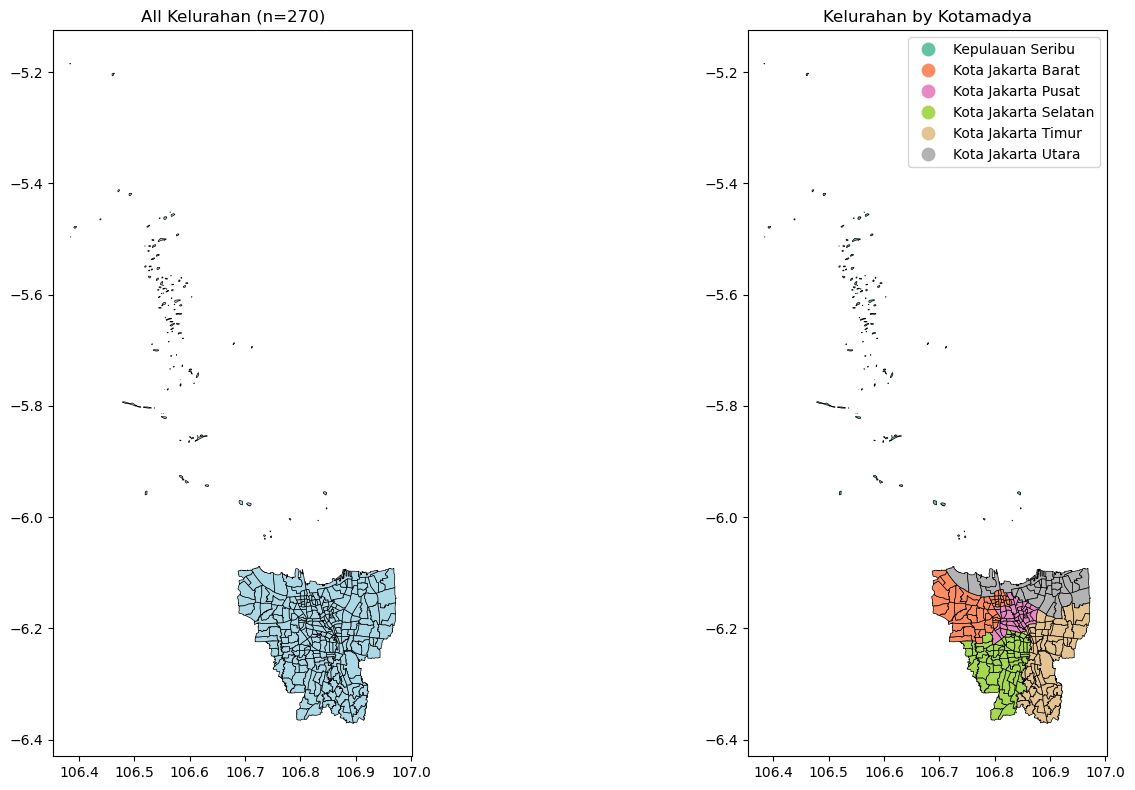

In [25]:
map_validation(kelurahan)

### EDA

In [28]:
kelurahan.head()

,Shape_Leng,Shape_Area,ADM4_EN,ADM4_PCODE,ADM4_REF,ADM4ALT1EN,ADM4ALT2EN,ADM3_EN,ADM3_PCODE,ADM2_EN,ADM2_PCODE,ADM1_EN,ADM1_PCODE,ADM0_EN,ADM0_PCODE,date,validOn,validTo,geometry
1689,0.234276,0.000659,Ancol,ID3175020003,NaN,NaN,None,Pademangan,ID3175020,Kota Jakarta Utara,ID3175,Dki Jakarta,ID31,Indonesia,ID,2019-12-20,2020-04-01,NaT,"POLYGON ((106.81881 -6.11509, 106.82042 -6.115..."
1835,0.034002,0.000064,Angke,ID3174050007,NaN,NaN,None,Tambora,ID3174050,Kota Jakarta Barat,ID3174,Dki Jakarta,ID31,Indonesia,ID,2019-12-20,2020-04-01,NaT,"POLYGON ((106.80086 -6.14844, 106.80052 -6.148..."
3584,0.097304,0.000138,Bale Kambang,ID3172050001,NaN,NaN,None,Kramat Jati,ID3172050,Kota Jakarta Timur,ID3172,Dki Jakarta,ID31,Indonesia,ID,2019-12-20,2020-04-01,NaT,"POLYGON ((106.8591 -6.26918, 106.85907 -6.2692..."
3663,0.039678,0.000055,Bali Mester,ID3172060007,NaN,NaN,None,Jatinegara,ID3172060,Kota Jakarta Timur,ID3172,Dki Jakarta,ID31,Indonesia,ID,2019-12-20,2020-04-01,NaT,"POLYGON ((106.86581 -6.21462, 106.86592 -6.214..."
3903,0.099691,0.000274,Bambu Apus,ID3172030006,NaN,NaN,None,Cipayung,ID3172030,Kota Jakarta Timur,ID3172,Dki Jakarta,ID31,Indonesia,ID,2019-12-20,2020-04-01,NaT,"POLYGON ((106.9077 -6.2997, 106.90828 -6.29972..."


In [30]:
kelurahan.describe()

,Shape_Leng,Shape_Area,date,validOn,validTo
count,270.000000,270.000000,270,270,0
mean,0.073042,0.000198,2019-12-20 00:00:00,2020-04-01 00:00:00,NaT
min,0.016430,0.000012,2019-12-20 00:00:00,2020-04-01 00:00:00,NaT
25%,0.044565,0.000080,2019-12-20 00:00:00,2020-04-01 00:00:00,NaT
50%,0.061709,0.000143,2019-12-20 00:00:00,2020-04-01 00:00:00,NaT
75%,0.093261,0.000262,2019-12-20 00:00:00,2020-04-01 00:00:00,NaT
max,0.566604,0.001051,2019-12-20 00:00:00,2020-04-01 00:00:00,NaT
std,0.047381,0.000166,NaN,NaN,NaN


In [32]:
kelurahan.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 270 entries, 1689 to 80715
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Shape_Leng  270 non-null    float64       
 1   Shape_Area  270 non-null    float64       
 2   ADM4_EN     270 non-null    str           
 3   ADM4_PCODE  270 non-null    str           
 4   ADM4_REF    0 non-null      str           
 5   ADM4ALT1EN  0 non-null      str           
 6   ADM4ALT2EN  0 non-null      object        
 7   ADM3_EN     270 non-null    str           
 8   ADM3_PCODE  270 non-null    str           
 9   ADM2_EN     270 non-null    str           
 10  ADM2_PCODE  270 non-null    str           
 11  ADM1_EN     270 non-null    str           
 12  ADM1_PCODE  270 non-null    str           
 13  ADM0_EN     270 non-null    str           
 14  ADM0_PCODE  270 non-null    str           
 15  date        270 non-null    datetime64[ms]
 16  validOn     270 no

In [34]:
kelurahan.columns.to_list()

['Shape_Leng',
 'Shape_Area',
 'ADM4_EN',
 'ADM4_PCODE',
 'ADM4_REF',
 'ADM4ALT1EN',
 'ADM4ALT2EN',
 'ADM3_EN',
 'ADM3_PCODE',
 'ADM2_EN',
 'ADM2_PCODE',
 'ADM1_EN',
 'ADM1_PCODE',
 'ADM0_EN',
 'ADM0_PCODE',
 'date',
 'validOn',
 'validTo',
 'geometry']

In [36]:
main_columns = ['Shape_Leng',
 'Shape_Area',
 'ADM4_EN',
 'ADM4_PCODE',
 'ADM3_EN',
 'ADM3_PCODE',
 'ADM2_EN',
 'ADM2_PCODE',
 'ADM1_EN',
 'ADM1_PCODE',
 'ADM0_EN',
 'ADM0_PCODE',
 'geometry'
               ]

In [38]:
kelurahan = kelurahan[main_columns]

In [40]:
kelurahan.head()

,Shape_Leng,Shape_Area,ADM4_EN,ADM4_PCODE,ADM3_EN,ADM3_PCODE,ADM2_EN,ADM2_PCODE,ADM1_EN,ADM1_PCODE,ADM0_EN,ADM0_PCODE,geometry
1689,0.234276,0.000659,Ancol,ID3175020003,Pademangan,ID3175020,Kota Jakarta Utara,ID3175,Dki Jakarta,ID31,Indonesia,ID,"POLYGON ((106.81881 -6.11509, 106.82042 -6.115..."
1835,0.034002,0.000064,Angke,ID3174050007,Tambora,ID3174050,Kota Jakarta Barat,ID3174,Dki Jakarta,ID31,Indonesia,ID,"POLYGON ((106.80086 -6.14844, 106.80052 -6.148..."
3584,0.097304,0.000138,Bale Kambang,ID3172050001,Kramat Jati,ID3172050,Kota Jakarta Timur,ID3172,Dki Jakarta,ID31,Indonesia,ID,"POLYGON ((106.8591 -6.26918, 106.85907 -6.2692..."
3663,0.039678,0.000055,Bali Mester,ID3172060007,Jatinegara,ID3172060,Kota Jakarta Timur,ID3172,Dki Jakarta,ID31,Indonesia,ID,"POLYGON ((106.86581 -6.21462, 106.86592 -6.214..."
3903,0.099691,0.000274,Bambu Apus,ID3172030006,Cipayung,ID3172030,Kota Jakarta Timur,ID3172,Dki Jakarta,ID31,Indonesia,ID,"POLYGON ((106.9077 -6.2997, 106.90828 -6.29972..."


In [42]:
kelurahan = kelurahan[kelurahan['ADM2_EN'] != 'Kepulauan Seribu']

In [44]:
kelurahan['ADM2_EN'].value_counts()

ADM2_EN
Kota Jakarta Timur      65
Kota Jakarta Selatan    65
Kota Jakarta Barat      57
Kota Jakarta Pusat      44
Kota Jakarta Utara      33
Name: count, dtype: int64

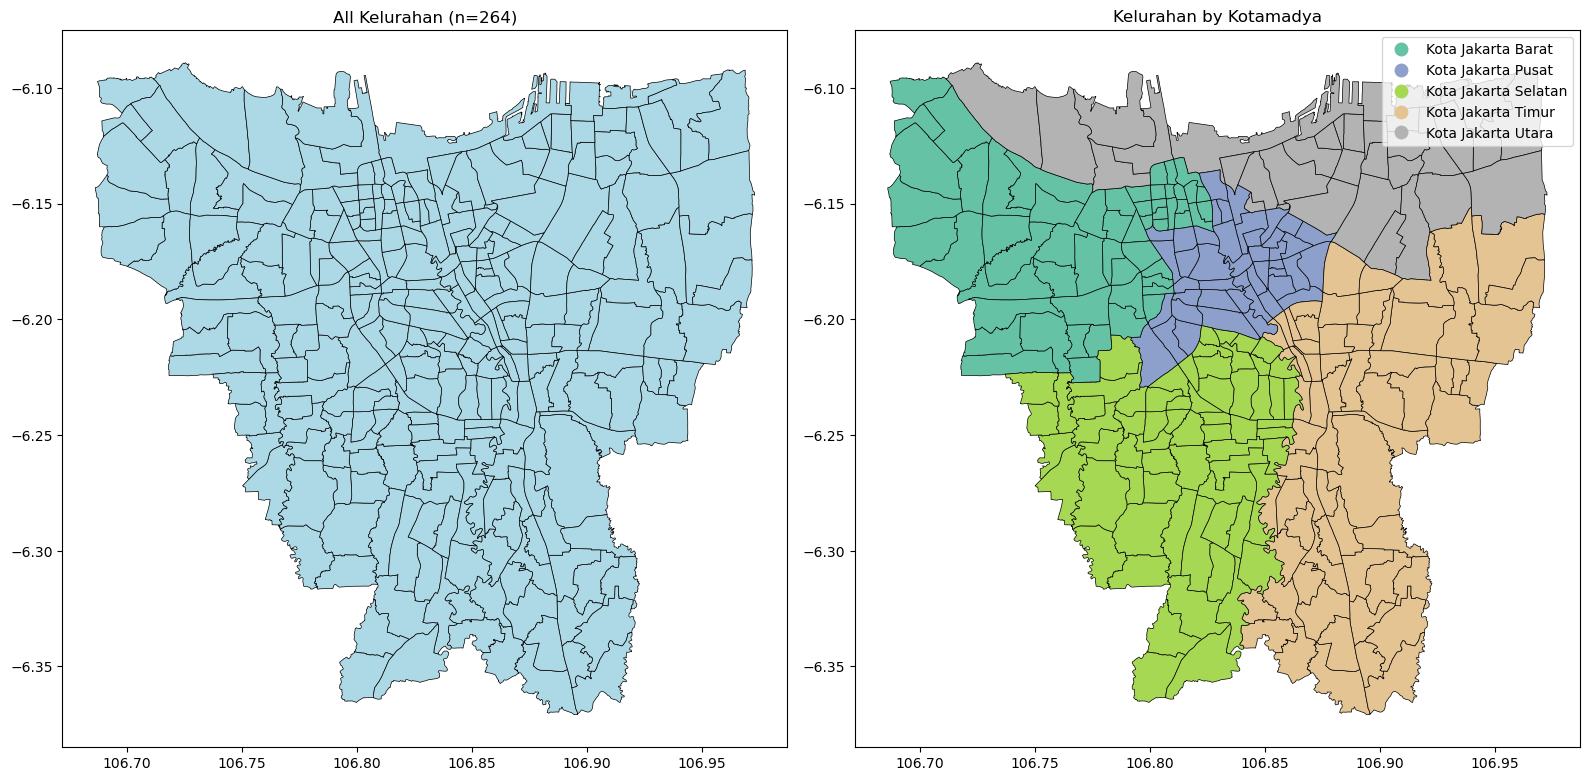

In [46]:
map_validation(kelurahan)

## Population Estimation

In [48]:
# Reproject to metric CRS first
CRS = "EPSG:32748"  # UTM Zone 48S
kelurahan = kelurahan.to_crs(CRS)

# Area-based population proxy (replace with WorldPop data if available)
# Assumes uniform density of ~15,000 people per km²  (Jakarta average)
kelurahan["area_km2"] = kelurahan.area / 1e6
kelurahan["population"] = (kelurahan["area_km2"] * 15000).round(0).astype(int)

In [50]:
kelurahan.head()

,Shape_Leng,Shape_Area,ADM4_EN,ADM4_PCODE,ADM3_EN,ADM3_PCODE,ADM2_EN,ADM2_PCODE,ADM1_EN,ADM1_PCODE,ADM0_EN,ADM0_PCODE,geometry,area_km2,population
1689,0.234276,0.000659,Ancol,ID3175020003,Pademangan,ID3175020,Kota Jakarta Utara,ID3175,Dki Jakarta,ID31,Indonesia,ID,"POLYGON ((701277.319 9323732.702, 701455.218 9...",8.074428,121116
1835,0.034002,0.000064,Angke,ID3174050007,Tambora,ID3174050,Kota Jakarta Barat,ID3174,Dki Jakarta,ID31,Indonesia,ID,"POLYGON ((699277.86 9320050.999, 699240.21 932...",0.786732,11801
3584,0.097304,0.000138,Bale Kambang,ID3172050001,Kramat Jati,ID3172050,Kota Jakarta Timur,ID3172,Dki Jakarta,ID31,Indonesia,ID,"POLYGON ((705677.839 9306675.062, 705674.479 9...",1.687470,25312
3663,0.039678,0.000055,Bali Mester,ID3172060007,Jatinegara,ID3172060,Kota Jakarta Timur,ID3172,Dki Jakarta,ID31,Indonesia,ID,"POLYGON ((706441.917 9312706.926, 706453.934 9...",0.674282,10114
3903,0.099691,0.000274,Bambu Apus,ID3172030006,Cipayung,ID3172030,Kota Jakarta Timur,ID3172,Dki Jakarta,ID31,Indonesia,ID,"POLYGON ((711044.756 9303280.323, 711108.471 9...",3.353529,50303


In [56]:
import pandas as pd

pd.set_option('display.max_rows', None)

In [58]:
kelurahan[['ADM4_EN', 'population']]

,ADM4_EN,population
1689,Ancol,121116
1835,Angke,11801
3584,Bale Kambang,25312
3663,Bali Mester,10114
3903,Bambu Apus,50303
4302,Bangka,47425
5461,Baru,28216
5833,Batu Ampar,37155
7021,Bendungan Hilir,23768
7731,Bidara Cina,18881


In [64]:
kelurahan.groupby(['ADM1_EN'])['population'].sum()

ADM1_EN
Dki Jakarta    9648553
Name: population, dtype: int64

In [66]:
kelurahan.groupby(['ADM1_EN', 'ADM2_EN'])['population'].sum()

ADM1_EN      ADM2_EN             
Dki Jakarta  Kota Jakarta Barat      1882289
             Kota Jakarta Pusat       718463
             Kota Jakarta Selatan    2172606
             Kota Jakarta Timur      2770687
             Kota Jakarta Utara      2104508
Name: population, dtype: int64

## Destination Point of Interest (POI)

This POI is according to osmnx feature

In [58]:
# POI tags that represent destinations (where people travel TO)
destination_tags = {
    "office": True,
    "amenity": ["school", "university", "hospital", "marketplace"],
    "shop": ["mall", "supermarket", "department_store"],
    "building": ["commercial", "office", "retail"]
}

pois = ox.features_from_place(
    "DKI Jakarta, Indonesia",
    tags=destination_tags
)

In [66]:
pois.head()

geometry       created_by  \
element id                                                       
node    309939284  POINT (106.81561 -6.19469)   Potlatch 0.10f   
        318548955  POINT (106.83066 -6.13323)  Merkaartor 0.12   
        319248799  POINT (106.79736 -6.22769)              NaN   
        321221315     POINT (106.81416 -6.22)              NaN   
        322773849  POINT (106.77454 -6.10717)   Potlatch 0.10f   

                                            name         shop         brand  \
element id                                                                    
node    309939284                      Hypermart  supermarket           NaN   
        318548955                    Grand Lucky  supermarket           NaN   
        319248799                   The FoodHall  supermarket  The FoodHall   
        321221315  Foodmart Fresh Plaza Semanggi  supermarket           NaN   
        322773849              Angke Fish Market  supermarket           NaN   

                          opening_hours                      owner  \
element id                                                           
node    309939284                   NaN                        NaN   
        318548955                   NaN                        NaN   
        319248799  PH,Mo-Su 10:00-22:00  PT. Swalayan Sukses Abadi   
        321221315           10:00-22:00                        NaN   
        322773849                   NaN                        NaN   

                  payment:coins payment:ep_tapcash payment:gopay_id  ...  \
element id                                                           ...   
node    309939284           NaN                NaN              NaN  ...   
        318548955           NaN                NaN              NaN  ...   
        319248799           yes                yes              yes  ...   
        321221315           NaN                NaN              NaN  ...   
        322773849           NaN                NaN              NaN  ...   

                  service service:vehicle:air_conditioning  \
element id                                                   
node    309939284     NaN                              NaN   
        318548955     NaN                              NaN   
        319248799     NaN                              NaN   
        321221315     NaN                              NaN   
        322773849     NaN                              NaN   

                  service:vehicle:alignment service:vehicle:batteries  \
element id                                                              
node    309939284                       NaN                       NaN   
        318548955                       NaN                       NaN   
        319248799                       NaN                       NaN   
        321221315                       NaN                       NaN   
        322773849                       NaN                       NaN   

                  service:vehicle:brakes service:vehicle:electrical  \
element id                                                            
node    309939284                    NaN                        NaN   
        318548955                    NaN                        NaN   
        319248799                    NaN                        NaN   
        321221315                    NaN                        NaN   
        322773849                    NaN                        NaN   

                  service:vehicle:transmission service:vehicle:tyres  \
element id                                                             
node    309939284                          NaN                   NaN   
        318548955                          NaN                   NaN   
        319248799                          NaN                   NaN   
        321221315                          NaN                   NaN   
        322773849                          NaN                   NaN   

                  service:vehicle:motor craft 

In [68]:
pois.columns.to_list()

['geometry',
 'created_by',
 'name',
 'shop',
 'brand',
 'opening_hours',
 'owner',
 'payment:coins',
 'payment:ep_tapcash',
 'payment:gopay_id',
 'payment:gpn_debit',
 'payment:jcb',
 'payment:maestro',
 'payment:mastercard',
 'payment:visa',
 'payment:visa_debit',
 'payment:visa_electron',
 'brand:wikidata',
 'brand:wikipedia',
 'addr:city',
 'addr:housenumber',
 'addr:postcode',
 'addr:street',
 'branch',
 'amenity',
 'type',
 'building',
 'addr:full',
 'operator:type',
 'school:type_idn',
 'source',
 'addr:floor',
 'admin_level',
 'check_date',
 'level',
 'name:id',
 'office',
 'wheelchair',
 'addr:country',
 'addr:housename',
 'alt_name',
 'isced:level',
 'check_date:currency:XBT',
 'phone',
 'website',
 'smoking',
 'corridor11',
 'note',
 'shelter',
 'shelter_tj',
 'addr:district',
 'description',
 'payment:cash',
 'payment:credit_cards',
 'payment:debit_cards',
 'email',
 'name:en',
 'addr:rt',
 'addr:rw',
 'access',
 'addr:place',
 'entrance',
 'barrier',
 'government',
 'addr:

In [70]:
pois.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 9804 entries, ('node', np.int64(309939284)) to ('way', np.int64(1489636031))
Columns: 336 entries, geometry to craft
dtypes: geometry(1), str(335)
memory usage: 25.2+ MB


In [72]:
pois.describe()

,geometry,created_by,name,shop,brand,opening_hours,owner,payment:coins,payment:ep_tapcash,payment:gopay_id,...,service,service:vehicle:air_conditioning,service:vehicle:alignment,service:vehicle:batteries,service:vehicle:brakes,service:vehicle:electrical,service:vehicle:transmission,service:vehicle:tyres,service:vehicle:motor,craft
count,9804,7,9011,536,142,381,3,12,1,3,...,2,2,2,2,2,2,2,2,1,1
unique,9804,3,7576,16,47,113,3,1,1,1,...,1,1,1,1,1,1,1,1,1,1
top,POINT (106.8156052 -6.1946879),OOH POINT,Sekretariat RW 04,supermarket,Alfamart,24/7,PT. Swalayan Sukses Abadi,yes,yes,yes,...,repair,yes,yes,yes,yes,yes,yes,yes,yes,electronics_repair
freq,1,4,74,207,30,72,1,12,1,3,...,2,2,2,2,2,2,2,2,1,1


### Change all geometry types to points

In [88]:
print(pois.geometry.dtype)

geometry


In [90]:
help(pois.geometry)

Help on GeoSeries in module geopandas.geoseries object:

class GeoSeries(geopandas.base.GeoPandasBase, pandas.Series)
 |  GeoSeries(data=None, index=None, crs: 'Any | None' = None, **kwargs)
 |
 |  A Series object designed to store shapely geometry objects.
 |
 |  Parameters
 |  ----------
 |  data : array-like, dict, scalar value
 |      The geometries to store in the GeoSeries.
 |  index : array-like or Index
 |      The index for the GeoSeries.
 |  crs : value (optional)
 |      Coordinate Reference System of the geometry objects. Can be anything accepted by
 |      :meth:`pyproj.CRS.from_user_input() <pyproj.crs.CRS.from_user_input>`,
 |      such as an authority string (eg "EPSG:4326") or a WKT string.
 |
 |  kwargs
 |      Additional arguments passed to the Series constructor,
 |       e.g. ``name``.
 |
 |  Examples
 |  --------
 |  >>> from shapely.geometry import Point
 |  >>> s = geopandas.GeoSeries([Point(1, 1), Point(2, 2), Point(3, 3)])
 |  >>> s
 |  0    POINT (1 1)
 |  1 

In [92]:
pois.geometry.geom_type.value_counts()

Polygon         8549
Point           1249
MultiPolygon       6
Name: count, dtype: int64

In [94]:
# Step 1 - Separate geometry types
points   = pois[pois.geometry.geom_type == "Point"].copy()
non_pts  = pois[pois.geometry.geom_type != "Point"].copy()

# Step 2 - Convert non-points to representative points
# representative_point() is safer than centroid()
# because it always falls INSIDE the polygon
non_pts["geometry"] = non_pts.geometry.representative_point()

# Step 3 - Combine
pois_pts = gpd.GeoDataFrame(
    pd.concat([points, non_pts], ignore_index=True),
    geometry="geometry",
    crs=pois.crs
)

# Step 4 - Reproject to UTM
pois_pts = pois_pts.to_crs("EPSG:32748")

# Step 5 - Verify all are now Points
print(f"\nTotal POIs : {len(pois_pts)}")
print(pois_pts.geometry.geom_type.value_counts())
# Should show only Point ✅


Total POIs : 9804
Point    9804
Name: count, dtype: int64


## Save the data

In [148]:
kelurahan.to_file("data sources\\kelurahan_pop.gpkg", layer="kelurahan")
pois_pts.to_file("data sources\\destination_pois.gpkg", layer="pois")